In [1]:
from os.path import dirname, abspath,join
from os import makedirs, listdir
import sys
import numpy as np
import pandas as pd
import json
import re
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

root_path = dirname(abspath("./"))
import sys
sys.path.append(root_path)
from causaliT.evaluation.predict import *
from causaliT.evaluation.eval_sweeps import *
from causaliT.training.forecasters.transformer_forecaster import TransformerForecaster
from notebooks.lib import *

# plotting standard settings
plt.rcParams['figure.dpi'] = 100 #360 # standard is 360 but for set to 100 for practical visualization on the notebook
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['lines.linewidth'] = 1.5

datadir_path = r"../data/"

In [2]:
produce_file = True
filepath = "./eval/intervention_debug_short_scm6.csv"

if produce_file:

    experiments = [
        #(r"../experiments/stage_Lie_scm6_54245206", "Lie"),
        #(r"../experiments/stage_SoftMax_scm6_54245286", "SoftMax"),
        (r"../experiments/stage_Lie_hard_scm6_54308824", "Lie_hard"),
        (r"../experiments/stage_SoftMax_hard_scm6_54308894", "SoftMax_hard"),
    ]

    df = None


    intervention_fn_S1_0 = create_intervention_fn(interventions={1: 0.0})
    intervention_fn_S1_5 = create_intervention_fn(interventions={1: 5.0})
    intervention_fn_S1_m5 = create_intervention_fn(interventions={1: -5.0})

    for exp_path, exp_label in experiments:

        df_base = predict_from_experiment(exp_path, input_conditioning_fn=None)
        df_base["intervention"] = "baseline"

        df_S1_0 = predict_from_experiment(exp_path, input_conditioning_fn=intervention_fn_S1_0)
        df_S1_0["intervention"] = "S1=0"

        df_S1_5 = predict_from_experiment(exp_path, input_conditioning_fn=intervention_fn_S1_5)
        df_S1_5["intervention"] = "S1=5"

        df_S1_m5 = predict_from_experiment(exp_path, input_conditioning_fn=intervention_fn_S1_m5)
        df_S1_m5["intervention"] = "S1=-5"

        df_temp = pd.concat([df_base, df_S1_0, df_S1_5, df_S1_m5], axis=0)
        df_temp["experiment"] = exp_label

        if df is None:
            df = df_temp
        else:
            df = pd.concat([df, df_temp], axis=0)

    df.to_csv(filepath)
    
else:
    df = pd.read_csv(filepath)

df.head()

Seed set to 42


Detected architecture: StageCausalForecaster
Found 5 k-fold directories: ['k_0', 'k_1', 'k_2', 'k_3', 'k_4']
Processing k_0: epoch=9-train_loss=0.00.ckpt...


c:\Users\ScipioneFrancesco\Documents\Projects\causaliT\venv\Lib\site-packages\torch\__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)


  Loaded mask 'dec1_cross': shape torch.Size([2, 3]) from dec1_cross_att_mask.csv
  Loaded mask 'dec1_self': shape torch.Size([2, 2]) from dec1_self_att_mask.csv
  Loaded mask 'dec2_cross': shape torch.Size([2, 2]) from dec2_cross_att_mask.csv
  Loaded mask 'dec2_self': shape torch.Size([2, 2]) from dec2_self_att_mask.csv
✓ Loaded 4 DAG masks from c:\Users\ScipioneFrancesco\Documents\Projects\causaliT\notebooks\..\data\scm6
✓ Hard masks loaded from data directory for inference.
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:05<00:00, 27.58it/s] 
Seed set to 42


...

100%|██████████| 157/157 [00:06<00:00, 23.55it/s]
Seed set to 42


  ✓ Successfully processed k_3 (20000 rows)
Processing k_4: epoch=9-train_loss=0.00.ckpt...
  Loaded mask 'dec1_cross': shape torch.Size([2, 3]) from dec1_cross_att_mask.csv
  Loaded mask 'dec1_self': shape torch.Size([2, 2]) from dec1_self_att_mask.csv
  Loaded mask 'dec2_cross': shape torch.Size([2, 2]) from dec2_cross_att_mask.csv
  Loaded mask 'dec2_self': shape torch.Size([2, 2]) from dec2_self_att_mask.csv
✓ Loaded 4 DAG masks from c:\Users\ScipioneFrancesco\Documents\Projects\causaliT\notebooks\..\data\scm6
✓ Hard masks loaded from data directory for inference.
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 22.64it/s]


  ✓ Successfully processed k_4 (20000 rows)

Total predictions: 100000 rows from 5 folds


,sample_idx,pos_idx,pred_feat_0,trg_feat_0,trg_feat_1,kfold,checkpoint_name,intervention,experiment
0,0,0,0.491268,0.633081,6.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie_hard
1,0,1,0.583485,0.574417,7.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie_hard
2,1,0,0.219657,0.372677,6.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie_hard
3,1,1,0.419869,0.427328,7.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie_hard
4,2,0,0.235883,0.306541,6.0,k_0,epoch=9-train_loss=0.00.ckpt,baseline,Lie_hard


The baseline changes for each fold, meaning some of them must fit the data better than other.

<Axes: xlabel='pred_feat_0', ylabel='Count'>

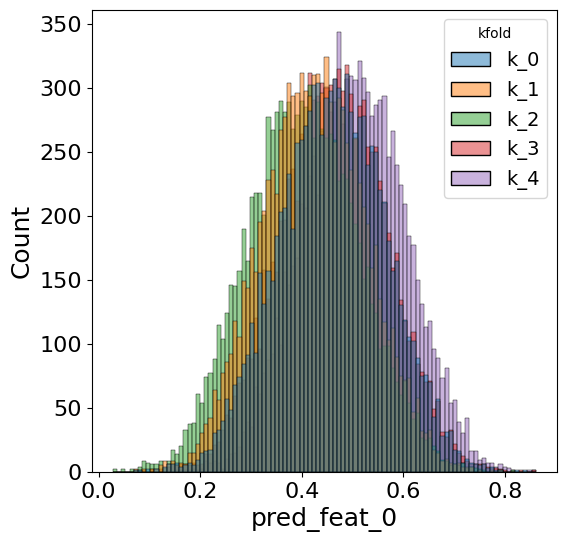

In [3]:
sns.histplot(data=df.set_index(["experiment", "trg_feat_1", "intervention"]).loc["Lie_hard"].loc[7.0].loc["baseline"], x="pred_feat_0", hue="kfold")

Different folds react differently on different interventions.

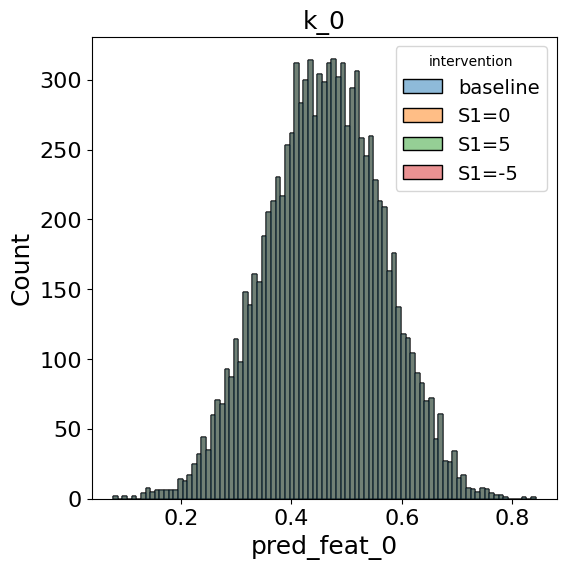

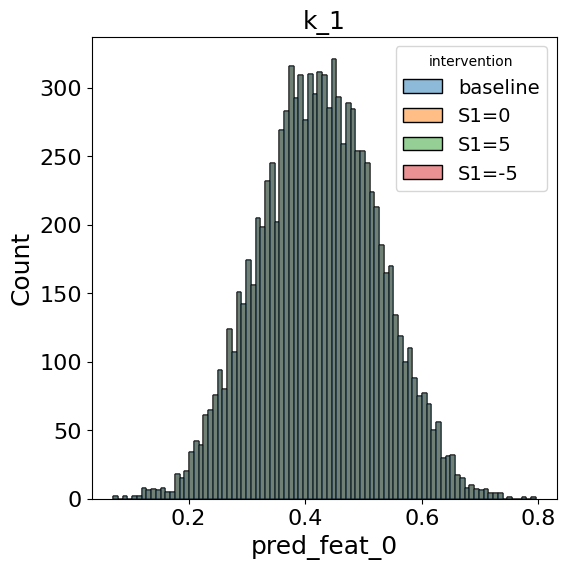

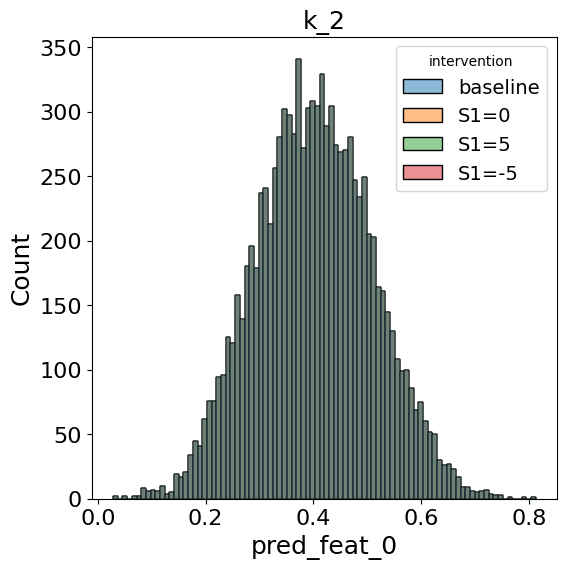

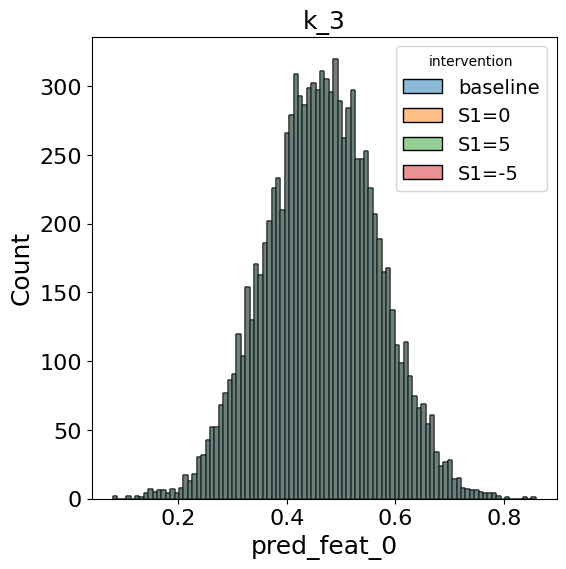

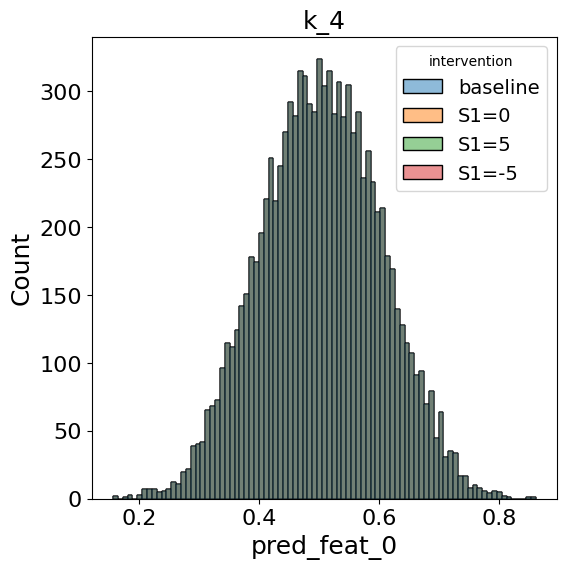

In [4]:
for k in ["k_0", "k_1", "k_2", "k_3", "k_4"]:
    plt.figure()
    sns.histplot(data=df.set_index(["experiment", "trg_feat_1", "kfold"]).loc["Lie_hard"].loc[7.0].loc[k], x="pred_feat_0", hue="intervention")
    plt.title(k)

# Calculating $\Delta_j=y_j - y_j^{do(S1:=s')}$

In [5]:
# Define the columns to use for matching
match_cols = ['sample_idx', 'pos_idx', 'kfold', 'checkpoint_name', 'experiment']

# Get baseline data
df_baseline = df[df['intervention'] == 'baseline'].copy()
df_baseline = df_baseline.set_index(match_cols)

# Get non-baseline data (interventions)
df_interventions = df[df['intervention'] != 'baseline'].copy()

# Compute deviation from baseline using merge
df_deviation = df_interventions.merge(
    df_baseline[['pred_feat_0', 'trg_feat_0', 'trg_feat_1']],
    on=match_cols,
    suffixes=('', '_baseline')
    )

# Calculate the deviation (difference from baseline)
df_deviation['pred_deviation'] = df_deviation['pred_feat_0'] - df_deviation['pred_feat_0_baseline']
df_deviation['trg_deviation'] = df_deviation['trg_feat_0'] - df_deviation['trg_feat_0_baseline']

# Drop the baseline columns if you don't need them anymore
df_deviation = df_deviation.drop(columns=['pred_feat_0_baseline', 'trg_feat_0_baseline', 'trg_feat_1_baseline'])

df_deviation
        

,sample_idx,pos_idx,pred_feat_0,trg_feat_0,trg_feat_1,kfold,checkpoint_name,intervention,experiment,pred_deviation,trg_deviation
0,0,0,-0.145353,0.633081,6.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie_hard,-0.636621,0.0
1,0,1,0.583485,0.574417,7.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie_hard,0.000000,0.0
2,1,0,-0.145322,0.372677,6.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie_hard,-0.364979,0.0
3,1,1,0.419869,0.427328,7.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie_hard,0.000000,0.0
4,2,0,-0.145167,0.306541,6.0,k_0,epoch=9-train_loss=0.00.ckpt,S1=0,Lie_hard,-0.381051,0.0
...,...,...,...,...,...,...,...,...,...,...,...
599995,9997,1,-0.122481,0.490103,7.0,k_4,epoch=9-train_loss=0.00.ckpt,S1=-5,SoftMax_hard,0.000000,0.0
599996,9998,0,-0.201017,0.464856,6.0,k_4,epoch=9-train_loss=0.00.ckpt,S1=-5,SoftMax_hard,-0.591614,0.0
599997,9998,1,-0.162417,0.402583,7.0,k_4,epoch=9-train_loss=0.00.ckpt,S1=-5,SoftMax_hard,0.000000,0.0
599998,9999,0,-0.198431,0.416391,6.0,k_4,epoch=9-train_loss=0.00.ckpt,S1=-5,SoftMax_hard,-0.472227,0.0


In [15]:
print(rf"Lie $\Delta$ mean: {df_deviation.set_index(["experiment", "trg_feat_1"]).loc["Lie_hard"].loc[7.0]["pred_deviation"].mean()}")
print(rf"Lie $\Delta$ std: {df_deviation.set_index(["experiment", "trg_feat_1"]).loc["Lie_hard"].loc[7.0]["pred_deviation"].std()}")
print(rf"SoftMax $\Delta$ mean: {df_deviation.set_index(["experiment", "trg_feat_1"]).loc["SoftMax_hard"].loc[7.0]["pred_deviation"].mean()}")
print(rf"SoftMax $\Delta$ std: {df_deviation.set_index(["experiment", "trg_feat_1"]).loc["SoftMax_hard"].loc[7.0]["pred_deviation"].std()}")

Lie $\Delta$ mean: 0.0
Lie $\Delta$ std: 0.0
SoftMax $\Delta$ mean: 0.0
SoftMax $\Delta$ std: 0.0
